# Notebook 01 — Data Loading

Load the jsons, inspect schema, count the rows and peak, cast a date column.

#### 1. Start Spark session

Connect to (or create) a Spark session and confirm whether we're running locally or on YARN.

In [1]:

from pyspark.sql import SparkSession
spark = SparkSession.builder.appName("PRAC").getOrCreate()
print("Master:", spark.sparkContext.master)

Master: yarn


26/04/27 06:53:07 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


#### 2. Load JSON and inspect schema

Read all JSON files from HDFS into a df. check out the schema. lets incldue the filename in the table, so we can extract snapshot date as well

In [2]:
from pyspark.sql.functions import input_file_name, regexp_extract, to_date,format_string
df = spark.read.json("/data/ProjectDatasetFacebookAU/")
df = df.withColumn("filename", input_file_name())

# extract YYYYMMDD from filename

date_re = r"-(\d{4})(\d{1,2})(\d{2})-"

yyyy = regexp_extract("filename", date_re, 1).cast("int")
mm   = regexp_extract("filename", date_re, 2).cast("int")
dd   = regexp_extract("filename", date_re, 3).cast("int")

date_str = format_string("%d-%02d-%02d", yyyy, mm, dd)

df = df.withColumn("snapshot_date", to_date(date_str, "yyyy-MM-dd"))

print(df.schema)

StructType([StructField('ad_creation_time', StringType(), True), StructField('ad_creative_bodies', ArrayType(StringType(), True), True), StructField('ad_creative_body', StringType(), True), StructField('ad_creative_link_caption', StringType(), True), StructField('ad_creative_link_captions', ArrayType(StringType(), True), True), StructField('ad_creative_link_description', StringType(), True), StructField('ad_creative_link_descriptions', ArrayType(StringType(), True), True), StructField('ad_creative_link_title', StringType(), True), StructField('ad_creative_link_titles', ArrayType(StringType(), True), True), StructField('ad_delivery_start_time', StringType(), True), StructField('ad_delivery_stop_time', StringType(), True), StructField('ad_snapshot_url', StringType(), True), StructField('bylines', StringType(), True), StructField('currency', StringType(), True), StructField('delivery_by_region', ArrayType(StructType([StructField('percentage', StringType(), True), StructField('region', Str

the 7 digit vs 8 digit date stamps in the filename got me. lets do a quick plot of snapshot date nulls to ensure i got them this time

In [3]:
from pyspark.sql.functions import col, sum, count, min, max

df.agg(
    count("*").alias("total"),
    sum(col("snapshot_date").isNull().cast("int")).alias("nulls"),
    count("snapshot_date").alias("non_nulls"),
    min("snapshot_date").alias("earliest"),
    max("snapshot_date").alias("latest"),
).show()

+--------+-----+---------+----------+----------+
|   total|nulls|non_nulls|  earliest|    latest|
+--------+-----+---------+----------+----------+
|39584139|    0| 39584139|2020-02-28|2024-03-21|
+--------+-----+---------+----------+----------+



#### 3. Row count and preview

Get a rough sense of data volume and check a sample of records.

In [4]:
df.show(5, truncate=80)
print("Row count:", df.count())

26/04/27 06:54:15 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+----------------+------------------+--------------------------------------------------------------------------------+------------------------+-------------------------+--------------------------------------------------------------------------------+-----------------------------+------------------------------+-----------------------+----------------------+---------------------+--------------------------------------------------------------------------------+-------+--------+------------------+--------------------------------------------------------------------------------+-----------------------+-----------------+----------------+------------+---------+----------------+-----------------+-------------------+-------------------+----------+--------------------------------------------------------------------------------+-------------+
|ad_creation_time|ad_creative_bodies|                                                                ad_creative_body|ad_creative_link_caption|ad_creative_lin

Row count: 39584139


#### 4. Cast ad_creation_time to date

ad_creation_time is loaded as a string. Add a typed ad_creation_datetime column alongside the original. 

turns out there's a more than one date format - lets do a check.

In [5]:
from pyspark.sql.functions import length, count, first

df.groupBy(length("ad_creation_time").alias("len")) \
  .agg(count("*").alias("count"), first("ad_creation_time").alias("example")) \
  .orderBy("len") \
  .show(truncate=False)

+---+--------+------------------------+
|len|count   |example                 |
+---+--------+------------------------+
|10 |39505667|2021-11-08              |
|24 |78472   |2020-08-28T05:47:41+0000|
+---+--------+------------------------+



given most of the data has the yyyy-mm-dd format, it's probably safe enough to just truncate everything to 10 characters to clean up the 80,000 odd ones

In [ ]:
from pyspark.sql.functions import to_date, substring

for src in ["ad_creation_time", "ad_delivery_start_time", "ad_delivery_stop_time"]:
    dst = src.replace("_time", "_date")
    df = df.withColumn(dst, to_date(substring(src, 1, 10), "yyyy-MM-dd"))

df.select("ad_creation_time", "ad_creation_date").show(5)

## 5. schema cleanup

there seems to be some adjacent schema entries, for example 
```
 |-- ad_creative_bodies: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- ad_creative_body: string (nullable = true)
```
what i'm going to try and do is groupBy month, then count the nulls in each column, then return the columns, months and counts to pandas/seaborn for plotting. this should allow us to visualise the schema changes over time.

ok i've realised this doesnt handle nested structs.

In [7]:
from pyspark.sql.functions import col

df = df.withColumn("estimated_audience_size_lower_bound", col("estimated_audience_size.lower_bound"))
df = df.withColumn("estimated_audience_size_upper_bound", col("estimated_audience_size.upper_bound"))
df = df.withColumn("impressions_lower_bound",            col("impressions.lower_bound"))
df = df.withColumn("impressions_upper_bound",            col("impressions.upper_bound"))
df = df.withColumn("spend_lower_bound",                  col("spend.lower_bound"))
df = df.withColumn("spend_upper_bound",                  col("spend.upper_bound"))

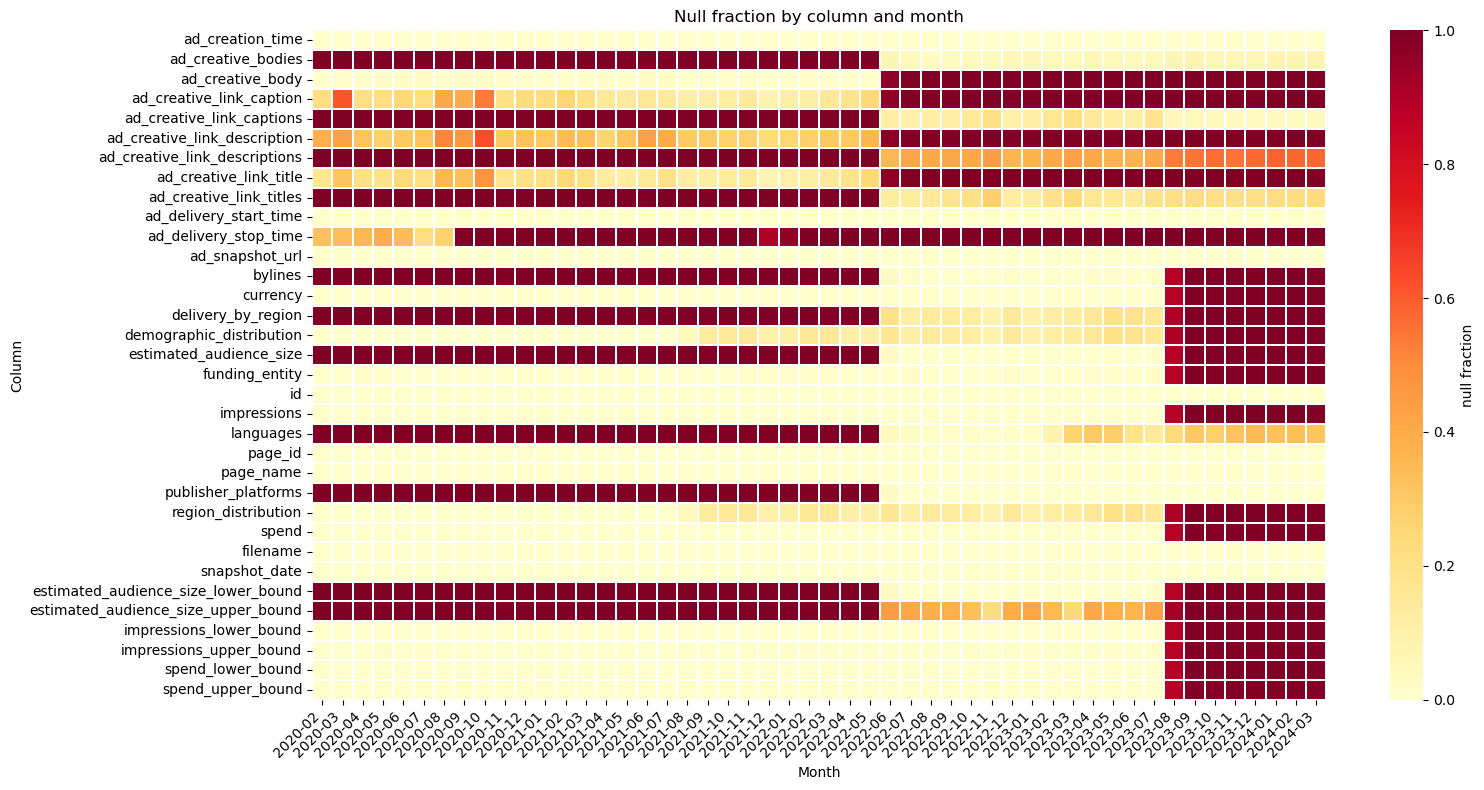

In [8]:
from pyspark.sql.functions import col, sum as spark_sum, count, date_trunc
import seaborn as sns
import matplotlib.pyplot as plt

cols = [c for c in df.columns if c != "ad_creation_date"]
agg_exprs = [count("*").alias("_total")] + [spark_sum(col(c).isNull().cast("int")).alias(c) for c in cols]

null_by_month = df \
    .withColumn("month", date_trunc("month", "snapshot_date")) \
    .groupBy("month") \
    .agg(*agg_exprs) \
    .orderBy("month")

pdf = null_by_month.toPandas()

months = pdf["month"]
totals = pdf["_total"]
frac = pdf[cols].divide(totals, axis=0)
frac.index = months
plt.figure(figsize=(16, 8))
frac.index = frac.index.strftime("%Y-%m")
sns.heatmap(
    frac.T,
    cmap="YlOrRd",
    vmin=0, vmax=1,
    linewidths=0.3,
    cbar_kws={"label": "null fraction"}
)
plt.title("Null fraction by column and month")
plt.xlabel("Month")
plt.ylabel("Column")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

so some things to note from comparing the heat map to the release notes:

there was a significant API update in June 2022, which loosely correlates with the release of Graph API version v13.0 in Feb 2022. The most noticable changes here where multiple changes from singular to arrays. There are also some renamed fields and some new fields.

looks like things broke singificantly in August 2023.


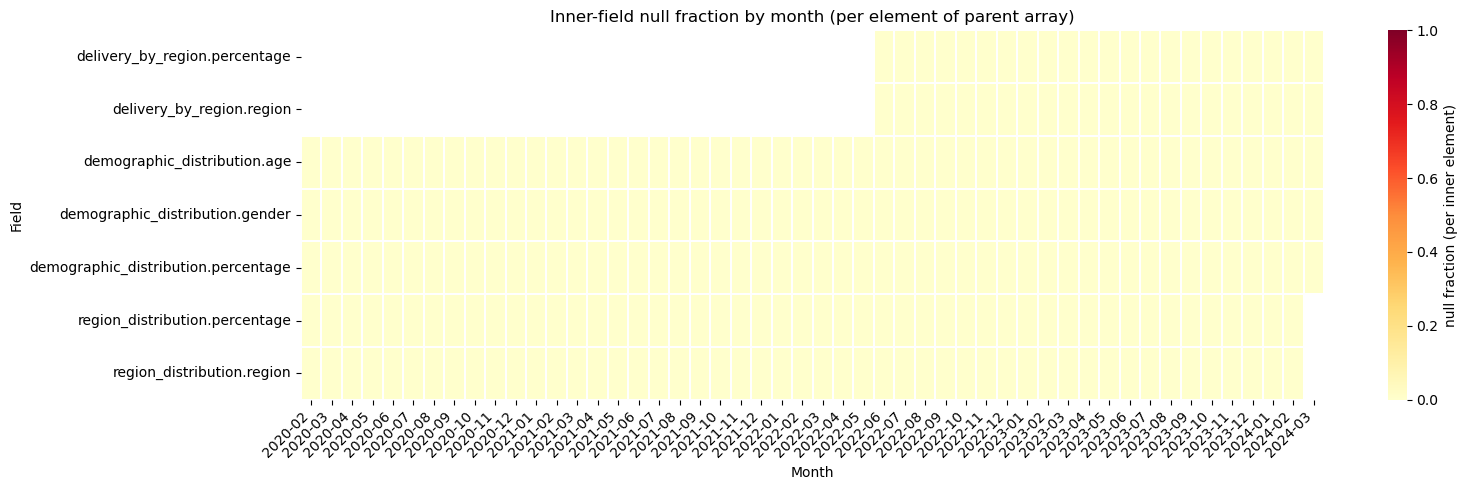

In [9]:
from pyspark.sql.functions import col, sum as spark_sum, count, date_trunc, explode, lit, when
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

array_struct_fields = {
    "delivery_by_region":       ["percentage", "region"],
    "demographic_distribution": ["age", "gender", "percentage"],
    "region_distribution":      ["percentage", "region"],
}

frames = []

for parent, children in array_struct_fields.items():
    exploded = df \
        .filter(col(parent).isNotNull()) \
        .withColumn("e", explode(parent)) \
        .withColumn("month", date_trunc("month", "snapshot_date"))

    agg_exprs = [count("*").alias("_total")] + [
        spark_sum(col(f"e.{c}").isNull().cast("int")).alias(c) for c in children
    ]

    by_month = exploded.groupBy("month").agg(*agg_exprs).orderBy("month").toPandas()
    totals = by_month["_total"]
    frac = by_month[children].divide(totals, axis=0)
    # rename to parent.child for the heatmap label
    frac.columns = [f"{parent}.{c}" for c in children]
    frac.index = pd.to_datetime(by_month["month"]).dt.strftime("%Y-%m")
    frames.append(frac)

# combine into one wide table (months × all child fields)
combined = pd.concat(frames, axis=1).sort_index()

plt.figure(figsize=(16, 5))
sns.heatmap(
    combined.T,
    cmap="YlOrRd",
    vmin=0, vmax=1,
    linewidths=0.3,
    cbar_kws={"label": "null fraction (per inner element)"}
)
plt.title("Inner-field null fraction by month (per element of parent array)")
plt.xlabel("Month")
plt.ylabel("Field")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

in 2022 some columns where changed from singular to arrays. choices are a) keep the first element from the array, drop the rest and keep everything as singular, or b) turn the singulars into single element arrays. I've gone with b) as it doesnt blow away the data.


we should also collapse a few more first: bylines and funding entiries, and delivery_by_region and region_distribution.  but first lets check they're duplicated fields

In [10]:
# delivery_by_region vs region_distribution mismatches
df.filter(
    col("delivery_by_region").isNotNull() & 
    col("region_distribution").isNotNull() & 
    (col("delivery_by_region") != col("region_distribution"))
) \
.select("delivery_by_region", "region_distribution") \
.show(20, truncate=False)

+------------------+-------------------+
|delivery_by_region|region_distribution|
+------------------+-------------------+
+------------------+-------------------+



In [11]:
# funding_entity vs bylines mismatches
df.filter(
    col("funding_entity").isNotNull() & 
    col("bylines").isNotNull() & 
    (col("funding_entity") != col("bylines"))
) \
.groupBy("funding_entity", "bylines") \
.count() \
.orderBy("count", ascending=False) \
.show(20, truncate=False)

+--------------+-------+-----+
|funding_entity|bylines|count|
+--------------+-------+-----+
+--------------+-------+-----+



In [ ]:
df.createOrReplaceTempView("ads")

df = spark.sql("""
    SELECT
        id,
        page_id,
        page_name,
        snapshot_date,
        ad_creation_date,
        ad_delivery_start_date,
        ad_delivery_stop_date,
        coalesce(ad_creative_bodies,            array(ad_creative_body))             AS creative_bodies,
        coalesce(ad_creative_link_captions,     array(ad_creative_link_caption))     AS creative_link_captions,
        coalesce(ad_creative_link_descriptions, array(ad_creative_link_description)) AS creative_link_descs,
        coalesce(ad_creative_link_titles,       array(ad_creative_link_title))       AS creative_link_titles,
        impressions,
        spend,
        estimated_audience_size,
        currency,
        languages,
        publisher_platforms,
        demographic_distribution,
        coalesce(delivery_by_region, region_distribution) AS delivery_by_region,
        ad_snapshot_url,
        coalesce(bylines, funding_entity) AS bylines
    FROM ads
""")

and lets regroup and replot.

do i have to do this again from scratch? it only takes a minute at this point, so i've just cut and paste for now

['id', 'page_id', 'page_name', 'ad_creation_time', 'snapshot_date', 'ad_delivery_start_time', 'ad_delivery_stop_time', 'creative_bodies', 'creative_link_captions', 'creative_link_descs', 'creative_link_titles', 'impressions', 'spend', 'currency', 'languages', 'publisher_platforms', 'demographic_distribution', 'estimated_audience_size', 'ad_snapshot_url', 'bylines', 'delivery_by_region']


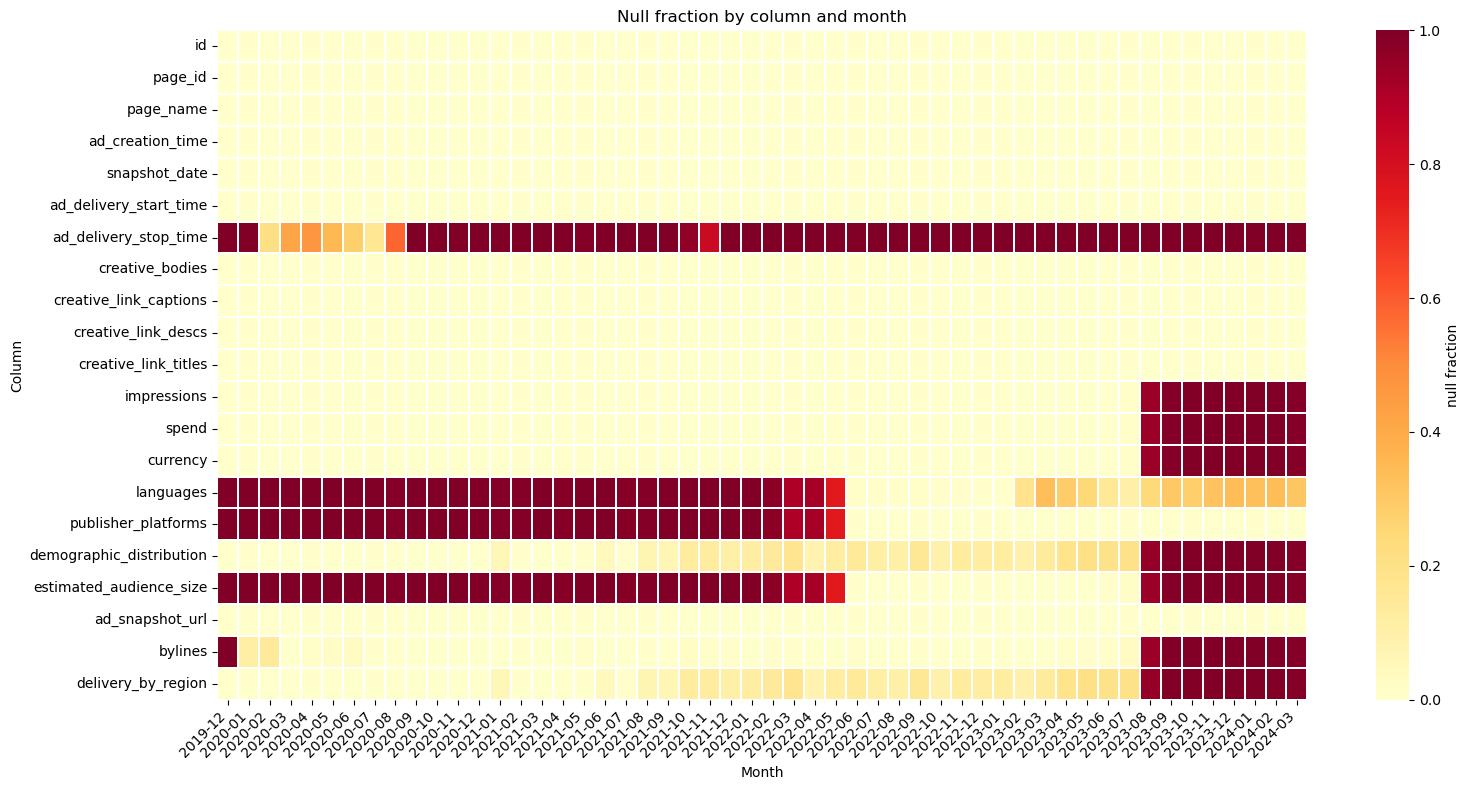

In [13]:
from pyspark.sql.functions import col, sum as spark_sum, count, date_trunc
import seaborn as sns
import matplotlib.pyplot as plt

cols = [c for c in df.columns if c != "ad_creation_date"]
print(cols)
agg_exprs = [count("*").alias("_total")] + [spark_sum(col(c).isNull().cast("int")).alias(c) for c in cols]

null_by_month = df \
    .withColumn("month", date_trunc("month", "ad_creation_date")) \
    .groupBy("month") \
    .agg(*agg_exprs) \
    .orderBy("month")

pdf = null_by_month.toPandas()

months = pdf["month"]
totals = pdf["_total"]
frac = pdf[cols].divide(totals, axis=0)
frac.index = months
plt.figure(figsize=(16, 8))
frac.index = frac.index.strftime("%Y-%m")
sns.heatmap(
    frac.T,
    cmap="YlOrRd",
    vmin=0, vmax=1,
    linewidths=0.3,
    cbar_kws={"label": "null fraction"}
)
plt.title("Null fraction by column and month")
plt.xlabel("Month")
plt.ylabel("Column")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

schema's settled. now to cut down to the election window, flatten the numeric structs, tag each row with a snapshot sequence, and write parquet.

#### 6. Filter to a year around the 21 May 2022 federal election

The corpus covers Feb 2020 → Mar 2024 but we only care about the 2022 election. Cut to the 6 months *before* and 6 months *after* election day — a one-year window centred on the campaign. This lets us compare the election-driven spike (candidates, party-org ads, attack ads) against the steady-state advocacy that runs year-round (NGO campaigns, government info, ongoing issue advocacy). The pre/post contrast is the analytical hook for the temporal analysis downstream.

In [ ]:
df = df.filter(
    (col("ad_creation_date") >= "2021-11-21") &   # 6 months before election
    (col("ad_creation_date") <= "2022-11-21")     # 6 months after election
)
print("Rows after window filter:", df.count())

#### 7. Flatten the numeric structs

`spend`, `impressions`, and `estimated_audience_size` are nested structs with string `lower_bound`/`upper_bound`. cast to long and add a midpoint for easier aggregation later. drop the originals once we've pulled them apart.

In [ ]:
for parent, prefix in [
    ("spend",                   "spend"),
    ("impressions",             "impressions"),
    ("estimated_audience_size", "audience_size"),
]:
    lo = col(f"{parent}.lower_bound").cast("long")
    hi = col(f"{parent}.upper_bound").cast("long")
    df = df.withColumn(f"{prefix}_lower_bound", lo)
    df = df.withColumn(f"{prefix}_upper_bound", hi)
    df = df.withColumn(f"{prefix}_mid", (lo + hi) / 2.0)

df = df.drop("spend", "impressions", "estimated_audience_size")
df.select("spend_lower_bound", "spend_upper_bound", "spend_mid").show(5)

#### 8. Tag each row with its snapshot sequence

the same ad appears in multiple monthly snapshots. add `ad_seq_no` so 1 = most recent snapshot per ad, climbing into the past. makes "latest state of each ad" a one-filter operation downstream.

In [ ]:
from pyspark.sql.functions import row_number
from pyspark.sql.window import Window

w = Window.partitionBy("id").orderBy(col("snapshot_date").desc())
df = df.withColumn("ad_seq_no", row_number().over(w))

#### 9. Write the parquet

small corpus — coalesce to 8 files (~50MB each) so we're not littering HDFS with tiny shards.

In [ ]:
PARQUET_PATH = "/user/s3348393/main/preprocessing/v1/parquet"

df.coalesce(8).write.parquet(PARQUET_PATH, mode="overwrite")
print("Wrote:", PARQUET_PATH)